# batch generate file tags for the cleaned documents

In [1]:
from utils.dify import FileUploadClient, WorkFlowRunClient
from tqdm import tqdm
from wordcloud import WordCloud
from collections import Counter

import re
import os
import pathlib
import random
import shutil
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
TAG_API_KEY = "app-oEOOvu6QpkAxa5VfABwqiTL0"
UPLOAD_FILE_URL = "http://10.26.58.108/v1/files/upload"
WORKFLOW_RUN_URL = "http://10.26.58.108/v1/workflows/run"
USER = "abc-123"

file_upload_client = FileUploadClient(
    api_key=TAG_API_KEY, base_url=UPLOAD_FILE_URL, user=USER
)
workflow_run_client = WorkFlowRunClient(
    api_key=TAG_API_KEY, base_url=WORKFLOW_RUN_URL, user=USER
)
tags_target_folder = "D:\\project\\SABRE-RAG\\mineru"
tags_files = os.listdir(tags_target_folder)

tags_list = []
for file_path in tqdm(
    tags_files,
    desc="Tagging papers",
    total=len(tags_files),
):
    file_path = os.path.join(tags_target_folder, file_path)
    # upload the file to the server
    file_upload_response = file_upload_client.request(file_path)

    # get the file upload id
    file_upload_id = file_upload_response.get("id")
    # run the workflow with the file upload id as input parameter
    workflow_run_response = workflow_run_client.request(
        param_name="input_file", upload_file_id=file_upload_id
    )

    # get the result
    result = workflow_run_response.get("data", {}).get("outputs", {}).get("result", {})
    print(result)
    tags_list.append(result)

# 保存成为 jsonl 文件
with open("papers_tag.jsonl", "w", encoding="utf-8") as f:
    for tag in tqdm(tags_list, desc="Saving papers tag"):
        f.write(json.dumps(tag, ensure_ascii=False) + "\n")

    print("Papers tag saved successfully.")

Tagging papers:   0%|          | 1/645 [00:24<4:20:48, 24.30s/it]

{'file_name': '0001.md', 'title': 'In situ NMR Observation of Tin Trichloride-Activated Rhodium Dihydride Complexes Using Parahydrogen Induced Polarization', 'method': '1H-PHIP'}


Tagging papers:   0%|          | 2/645 [00:50<4:30:41, 25.26s/it]

{'file_name': '0002.md', 'title': 'Parahydrogen-induced polarization in the presence of NMR shift reagents', 'method': '1H-PHIP'}


Tagging papers:   0%|          | 3/645 [01:11<4:12:06, 23.56s/it]

...

{'file_name': '0644.md', 'title': 'Symmetry Constraints on Spin Order Transfer in Parahydrogen-Induced Polarization (PHIP)', 'method': '13C-PHIP'}


Tagging papers: 100%|██████████| 645/645 [8:50:14<00:00, 49.32s/it]


{'file_name': '0645.md', 'title': 'Live magnetic observation of parahydrogen hyperpolarization dynamics', 'method': '13C-SABRE-SHEATH'}


Saving papers tag: 100%|██████████| 645/645 [00:00<00:00, 214930.17it/s]

Papers tag saved successfully.


## 根据标签筛选文献

Papers tag loaded.
  file_name                                              title   method
0   0001.md  In situ NMR Observation of Tin Trichloride-Act...  1H-PHIP
1   0002.md  Parahydrogen-induced polarization in the prese...  1H-PHIP
2   0003.md  Examination of subsequent reaction products en...  1H-PHIP
3   0004.md  In situ NMR Detection of Dihydrides in the Sys...  1H-PHIP
4   0005.md  Mechanistic Aspects of Dihydrogen Activation a...  1H-PHIP


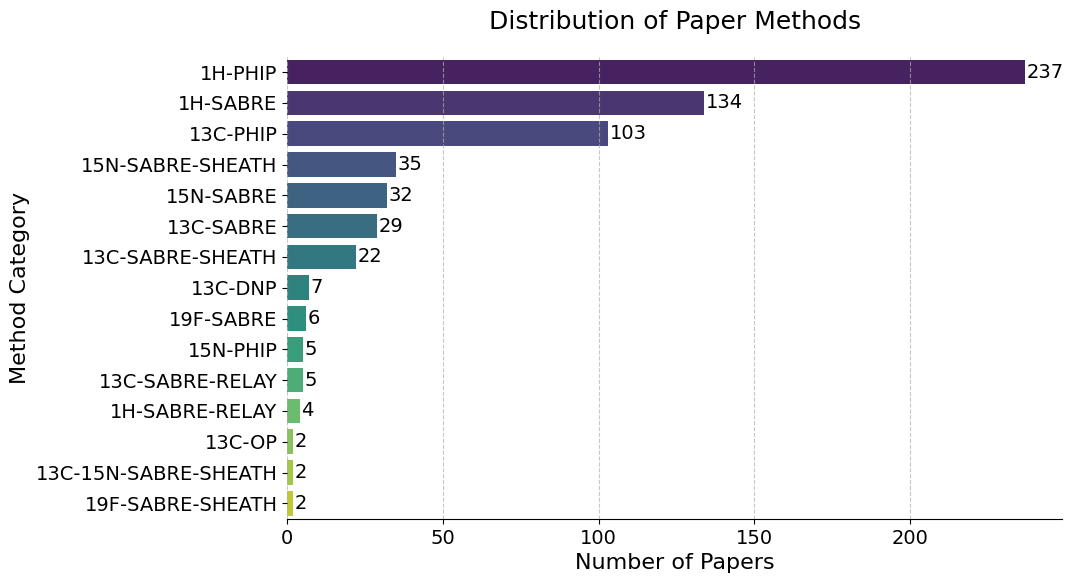

In [ ]:
# 首先读取 papers_tag.jsonl
papers_tags = pd.read_json('./outputs/papers_tag.jsonl', lines=True)
papers_tags['method'] = papers_tags['method'].fillna('nucleus-method')

# 将所有 'method': 'nucleus-method' 删除
papers_tags = papers_tags[papers_tags['method'] != 'nucleus-method']

print("Papers tag loaded.")
print(papers_tags.head())

# papers_tags
# file_name title method
# 绘制出 papers_tags 中所有的 method 的分布
# 如果有空值，将其修改为 nucleus-method
method_counts = papers_tags['method'].value_counts().reset_index()
method_counts.columns = ['method', 'count']
method_counts = method_counts.sort_values('count', ascending=False).head(15)  # 排序以便条形图从上到下显示

# 绘制柱状图
fig = plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='count',
    y='method',
    hue='method',
    data=method_counts.sort_values('count', ascending=False),
    palette='viridis',
    legend=False,
)

for p in ax.patches:
    width = p.get_width()
    plt.text(
        width + 0.5,
        p.get_y() + p.get_height()/2,
        f'{int(width)}',
        ha='left',
        va='center',
        fontsize=14
    )

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title('Distribution of Paper Methods', fontsize=18, pad=20)
plt.xlabel('Number of Papers', fontsize=16)
plt.ylabel('Method Category', fontsize=16)
plt.grid(axis='x', linestyle='--', alpha=0.7)
sns.despine(left=True)
fig.savefig('./outputs/method_distribution.pdf', dpi=300, bbox_inches='tight')

## Select files for constructing QAC dataset

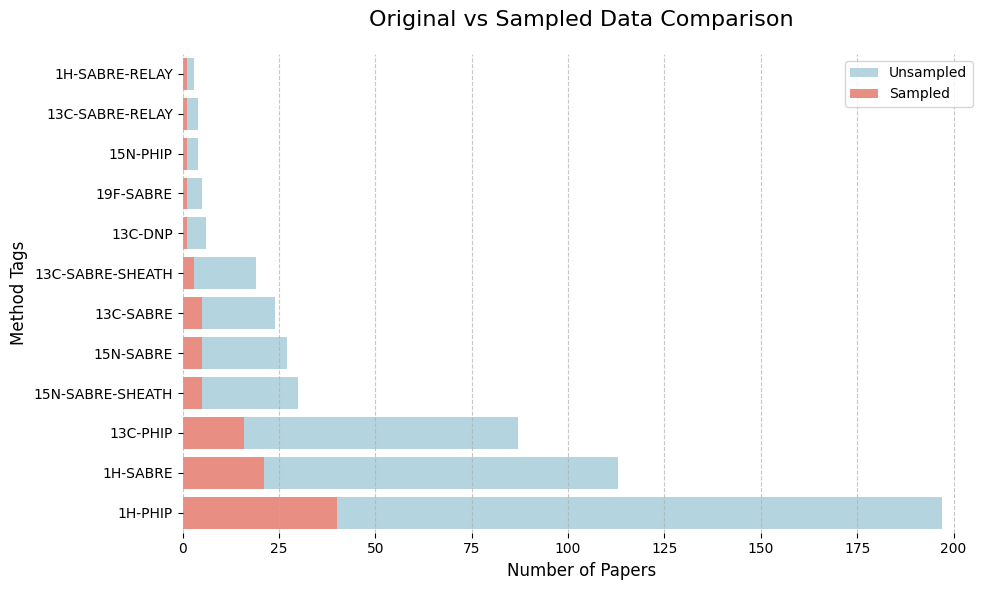

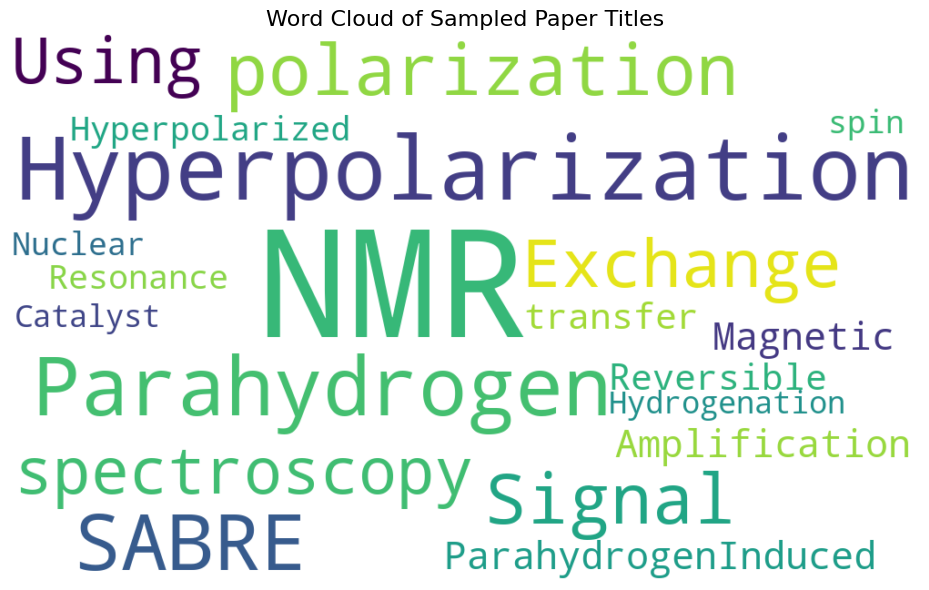

In [38]:
# 首先读取 papers_tag.jsonl
papers_tags = pd.read_json('papers_tag.jsonl', lines=True)
papers_tags['method'] = papers_tags['method'].fillna('nucleus-method')
# 将所有 'method': 'nucleus-method' 删除
papers_tags = papers_tags[papers_tags['method'] != 'nucleus-method']

# 分层抽样约100个样本
target_samples = 100
method_counts = papers_tags['method'].value_counts().reset_index()
method_counts.columns = ['method', 'count']

# 计算每个类别的抽样比例
method_counts['proportion'] = method_counts['count'] / method_counts['count'].sum()
method_counts['sample_size'] = (method_counts['proportion'] * target_samples).round().astype(int)

# 调整样本量使总数接近100
total = method_counts['sample_size'].sum()
if total < target_samples:
    method_counts.loc[method_counts['sample_size'].idxmax(), 'sample_size'] += target_samples - total
elif total > target_samples:
    method_counts.loc[method_counts['sample_size'].idxmax(), 'sample_size'] -= total - target_samples

# 执行分层抽样
sampled_papers = pd.DataFrame()
for _, row in method_counts.iterrows():
    method = row['method']
    size = row['sample_size']
    subset = papers_tags[papers_tags['method'] == method]

    if len(subset) < size:
        sampled = subset
    else:
        sampled = subset.sample(n=size, random_state=42)

    sampled_papers = pd.concat([sampled_papers, sampled])

sampled_papers.reset_index(drop=True, inplace=True)


# 计算原始数据分布
original_counts = papers_tags['method'].value_counts().reset_index()
original_counts.columns = ['method', 'original_count']

# 绘制抽样分布
sampled_counts = sampled_papers['method'].value_counts().reset_index()
sampled_counts.columns = ['method', 'sampled_count']

# 合并数据
combined = original_counts.merge(sampled_counts, on='method')
combined['unsampled_count'] = combined['original_count'] - combined['sampled_count']
combined['sampled_percentage'] = combined['sampled_count'] / combined['original_count'] * 100

stacked_df = pd.melt(
    combined,
    id_vars=['method', 'original_count', 'sampled_percentage'],
    value_vars=['unsampled_count', 'sampled_count'],
    var_name='category',
    value_name='count'
)

# 重命名类别
stacked_df['category'] = stacked_df['category'].map({
    'unsampled_count': 'Unsampled',
    'sampled_count': 'Sampled'
})

# 创建水平条形图
# 3. 绘制抽样分布柱状图
fig = plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x='count',
    y='method',
    hue='category',
    data=stacked_df.sort_values('original_count', ascending=True),
    palette={'Unsampled': 'lightblue', 'Sampled': 'salmon'},
    dodge=False  # Stacked instead of grouped
)

# 图表装饰
plt.title('Original vs Sampled Data Comparison', fontsize=16, pad=20)
plt.xlabel('Number of Papers', fontsize=12)
plt.ylabel('Method Tags', fontsize=12)
plt.legend(loc='upper right')
sns.despine(left=True, bottom=True)
ax.xaxis.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
# 保存为 pdf 文件方便后期修改
fig.savefig('sampling_distribution.pdf', dpi=300, bbox_inches='tight')

# 生成词云图
all_titles = ' '.join(sampled_papers['title'].tolist())
cleaned_text = re.sub(r'[^a-zA-Z0-9\s]', '', all_titles)
wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='white',
    max_words=20,
    colormap='viridis',
    collocations=False
).generate(cleaned_text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Sampled Paper Titles', fontsize=16)
plt.tight_layout()
plt.savefig('title_wordcloud.pdf', dpi=300, bbox_inches='tight')
plt.show()

# 保存
sampled_papers.to_csv('sampled_papers_100.csv', index=False)

In [41]:
# 读取 sampled_papers_100.csv
sampled_papers = pd.read_csv('sampled_papers_100.csv')

# 获取 file_name list
file_names = sampled_papers['file_name'].tolist()

# 将 mineru 文件中的 file_name 复制到 qac 文件夹中
mineru_folder = "D:\\project\\SABRE-RAG\\mineru"
qac_folder = "D:\\project\\SABRE-RAG\\qac_files"

for file_name in tqdm(file_names, desc="Copying files"):
    file_path = os.path.join(mineru_folder, file_name)
    shutil.copy(file_path, qac_folder)
    print(f"Copied {file_name} to {qac_folder}")

Copying files:  35%|███▌      | 35/100 [00:00<00:00, 343.92it/s]

Copied 0322.md to D:\project\SABRE-RAG\qac_files
Copied 0026.md to D:\project\SABRE-RAG\qac_files
Copied 0541.md to D:\project\SABRE-RAG\qac_files
Copied 0346.md to D:\project\SABRE-RAG\qac_files
Copied 0007.md to D:\project\SABRE-RAG\qac_files
Copied 0458.md to D:\project\SABRE-RAG\qac_files
Copied 0011.md to D:\project\SABRE-RAG\qac_files
Copied 0588.md to D:\project\SABRE-RAG\qac_files
Copied 0299.md to D:\project\SABRE-RAG\qac_files
Copied 0585.md to D:\project\SABRE-RAG\qac_files
Copied 0475.md to D:\project\SABRE-RAG\qac_files
Copied 0385.md to D:\project\SABRE-RAG\qac_files
Copied 0058.md to D:\project\SABRE-RAG\qac_files
Copied 0490.md to D:\project\SABRE-RAG\qac_files
Copied 0305.md to D:\project\SABRE-RAG\qac_files
Copied 0121.md to D:\project\SABRE-RAG\qac_files
Copied 0040.md to D:\project\SABRE-RAG\qac_files
Copied 0521.md to D:\project\SABRE-RAG\qac_files
Copied 0221.md to D:\project\SABRE-RAG\qac_files
Copied 0032.md to D:\project\SABRE-RAG\qac_files
Copied 0525.md to D:

Copying files: 100%|██████████| 100/100 [00:00<00:00, 331.37it/s]

Copied 0225.md to D:\project\SABRE-RAG\qac_files
Copied 0578.md to D:\project\SABRE-RAG\qac_files
Copied 0244.md to D:\project\SABRE-RAG\qac_files
Copied 0095.md to D:\project\SABRE-RAG\qac_files
Copied 0018.md to D:\project\SABRE-RAG\qac_files
Copied 0148.md to D:\project\SABRE-RAG\qac_files
Copied 0195.md to D:\project\SABRE-RAG\qac_files
Copied 0610.md to D:\project\SABRE-RAG\qac_files
Copied 0546.md to D:\project\SABRE-RAG\qac_files
Copied 0454.md to D:\project\SABRE-RAG\qac_files
Copied 0048.md to D:\project\SABRE-RAG\qac_files
Copied 0421.md to D:\project\SABRE-RAG\qac_files
Copied 0307.md to D:\project\SABRE-RAG\qac_files
Copied 0388.md to D:\project\SABRE-RAG\qac_files
Copied 0365.md to D:\project\SABRE-RAG\qac_files
Copied 0321.md to D:\project\SABRE-RAG\qac_files
Copied 0614.md to D:\project\SABRE-RAG\qac_files
Copied 0326.md to D:\project\SABRE-RAG\qac_files
Copied 0461.md to D:\project\SABRE-RAG\qac_files
Copied 0371.md to D:\project\SABRE-RAG\qac_files
Copied 0213.md to D:

## Gernerate QAC dataset using batch processing

In [ ]:
from utils.dify import FileUploadClient, WorkFlowRunClient
from tqdm import tqdm
import os

QAC_API_KEY = "app-GUZY4C4r4OX63iaTkX7tBcLq"
UPLOAD_FILE_URL = "http://10.26.58.108/v1/files/upload"
WORKFLOW_RUN_URL = "http://10.26.58.108/v1/workflows/run"
qac_target_folder = "D:\\project\\SABRE-RAG\\qac_files"
qac_files = os.listdir(qac_target_folder)

USER = "abc-123"

file_upload_client = FileUploadClient(
    api_key=QAC_API_KEY, base_url=UPLOAD_FILE_URL, user=USER
)
workflow_run_client = WorkFlowRunClient(
    api_key=QAC_API_KEY, base_url=WORKFLOW_RUN_URL, user=USER
)

qac_list = []
for file_path in tqdm(qac_files, desc="Generating QAC dataset", total=len(qac_files)):
    file_path = os.path.join(qac_target_folder, file_path)
    # upload the file to the server
    file_upload_response = file_upload_client.request(file_path)
    # get the file upload id
    file_upload_id = file_upload_response.get("id")

    # run the workflow with the file upload id as input parameter
    workflow_run_response = workflow_run_client.request(
        param_name="input_file", upload_file_id=file_upload_id
    )
    # result is the list of dict
    result = workflow_run_response.get("data", {}).get("outputs", {}).get("result", {})
    # extend result list to qac_list
    qac_list.extend(result)

# 保存成为 jsonl 文件
with open("qac_dataset.jsonl", "w", encoding="utf-8") as f:
    for qac in tqdm(qac_list, desc="Saving qac dataset"):
        f.write(json.dumps(qac, ensure_ascii=False) + "\n")

    print("QAC Dataset JSONL saved successfully.")

Generating QAC dataset:   0%|          | 0/100 [00:00<?, ?it/s]

In [7]:
from utils.dify import WorkFlowLogClient
from tqdm import tqdm

QAC_API_KEY = "app-GUZY4C4r4OX63iaTkX7tBcLq"
WORKFLOW_LOG_URL = "http://10.26.58.108/v1/workflows/logs"

workflow_log_client = WorkFlowLogClient(
    api_key=QAC_API_KEY,
    base_url=WORKFLOW_LOG_URL,
    user="abc-123"
)

page = 1
data_list = []
while True:
    # 如果 page 大于设定值则退出
    if page > 2:
       break
    
    logs = workflow_log_client.request(page=page, limit=50)
    # 拿到 logs 中的 data 
    data = logs.get("data", [])
    data_list.extend(data)     
       
    page += 1


# 拿到 data_list 中的所有 workflow_run 中的 id
workflow_run_id_list = []
for data in tqdm(data_list):
    id = data.get("workflow_run").get("id")
    workflow_run_id_list.append(id)
    
print(workflow_run_id_list)

100%|██████████| 100/100 [00:00<00:00, 2016492.31it/s]

['95995e11-dafc-41c6-b8b9-e3b4ad2d53d8', '92d12ae5-21d4-4b42-bb6d-19c99ac8ef2a', 'c6cc42a5-f818-4235-a315-40ff01bddb8e', '0c70af08-b5e8-41c4-a064-e1a39d14d3d4', '838850e7-bb96-4c06-aea1-11ac46ddf875', 'a59128db-61de-4625-adac-41ec30ad01dc', 'bb5df8ee-6054-4b4f-aa7d-d3b22e3f579d', '1e2021ce-5801-4809-a5b6-e229cdab5675', 'f8aad8ff-a1fa-417d-b9f6-322e171e47bd', '1375b6af-795c-487b-a323-fe3d13c902ad', 'c81c22c5-ede1-4f20-8bc4-c4b468f4b304', 'fe53b9c2-c4b7-494e-ab93-64d19cf8f1ac', '42feed17-fcd7-4ea8-9dc4-7917da1673e1', '29f3af1b-bc98-48b9-ab31-9f43e317fba0', '644c3459-9728-4bf4-afa4-539bdb961d2e', '4b37bc28-0478-4b44-a709-a278e9fa9d59', '4912102f-2666-435d-bb05-a04eb357ae6f', '99f1336d-29c8-45e8-bd80-9878d11ec089', 'e84b9bc0-bd03-4389-811e-c2f4f7454731', '275bafe4-2d20-4c87-89f2-1acbc885ff99', 'b583f831-c819-47ba-a758-b39414e40f10', 'eab34f7d-714d-40b4-b844-10984745066b', 'dc887d37-6e88-4135-846c-45db57c9a09a', 'bad19f07-9fbe-4f9f-a6b1-b10950fe8fd3', 'ca04b27c-9703-4ceb-b7c3-9b3607001620',

In [19]:
from utils.dify import WorkFlowRunClient
from tqdm import tqdm
import json

QAC_API_KEY = "app-GUZY4C4r4OX63iaTkX7tBcLq"
WORKFLOW_RUN_URL = "http://10.26.58.108/v1/workflows/run"

workflow_run_client = WorkFlowRunClient(
    api_key=QAC_API_KEY,
    base_url=WORKFLOW_RUN_URL,
    user="abc-132"
)

qac_list = []
for workflow_run_id in tqdm(workflow_run_id_list):
    res = workflow_run_client.get_info(workflow_run_id)
    outputs = json.loads(res.get("outputs", {}))
    qac = outputs.get("result", [])
    qac_list.extend(qac)
    

# 清理 qac_list 中的 NaN
clean_qac_list = [
    qac for qac in qac_list 
    if qac is not None 
    and qac.get("question") != "NaN" 
    and qac.get("answer") != "NaN" 
    and qac.get("context") != "NaN"
]
    
# 保存成为 jsonl 文件
with open("qac_dataset.jsonl", "w", encoding="utf-8") as f:
    for qac in tqdm(clean_qac_list, desc="Saving qac dataset"):
        f.write(json.dumps(qac, ensure_ascii=False) + "\n")

    print("QAC Dataset JSONL saved successfully.")

Saving qac dataset: 100%|██████████| 1403/1403 [00:00<00:00, 107938.82it/s]

QAC Dataset JSONL saved successfully.
